In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statistics as sts

In [38]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [39]:
df.shape

(1470, 35)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Text(0.5, 1.0, 'Age')

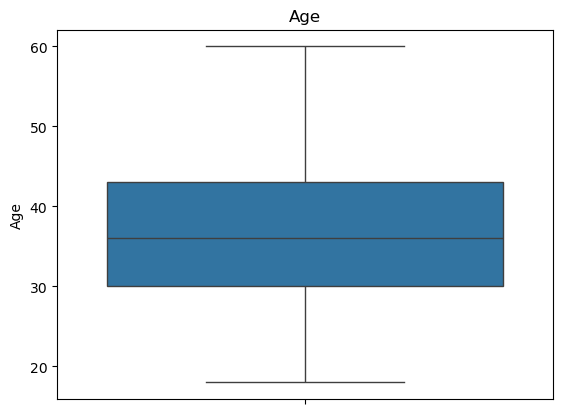

In [41]:
sns.boxplot(df['Age']).set_title('Age')

Text(0.5, 1.0, 'Age')

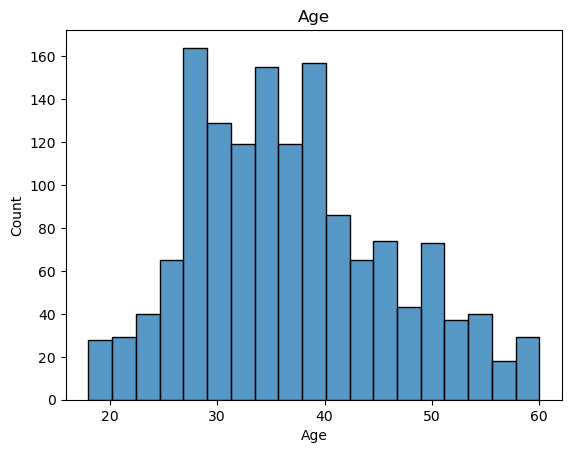

In [42]:
sns.histplot(df['Age']).set_title('Age')

In [43]:
median_age = sts.median(df['Age'])
median_age

36.0

In [44]:
df['Attrition'].value_counts()

No     1233
Yes     237
Name: Attrition, dtype: int64

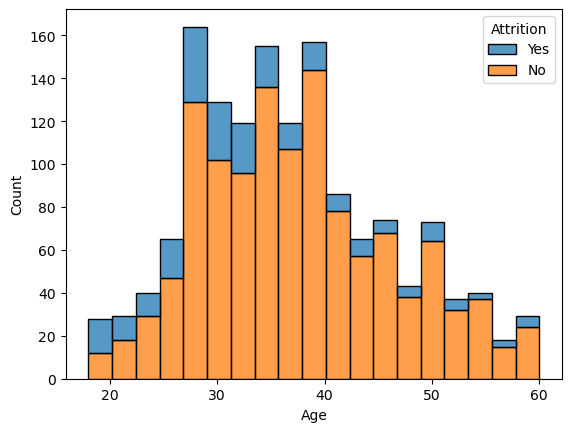

In [45]:
# Attrition x Age
sns.histplot(data=df, x='Age', hue='Attrition', multiple='stack')
plt.show()

<Axes: xlabel='EducationField'>

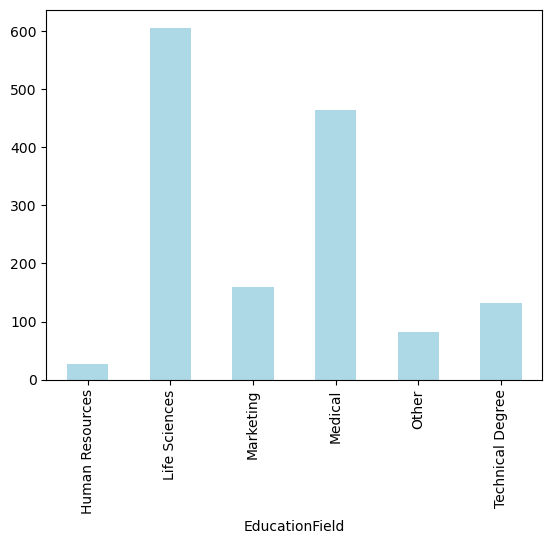

In [46]:
education_field = df.groupby(['EducationField']).size()
education_field.plot.bar(color = 'lightblue')

<Axes: xlabel='Gender'>

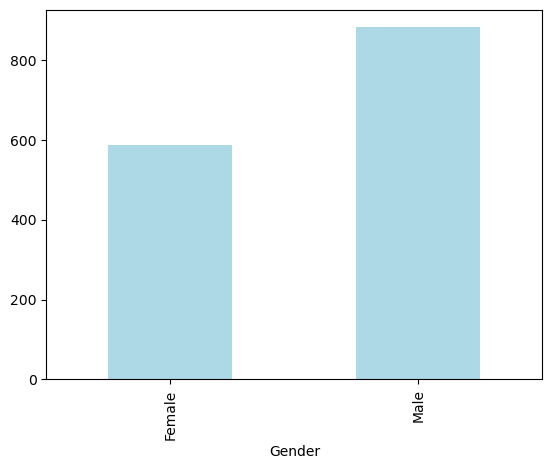

In [47]:
gender = df.groupby(['Gender']).size()
gender.plot.bar(color = 'lightblue')

In [48]:
df['MonthlyIncome'].describe()

count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

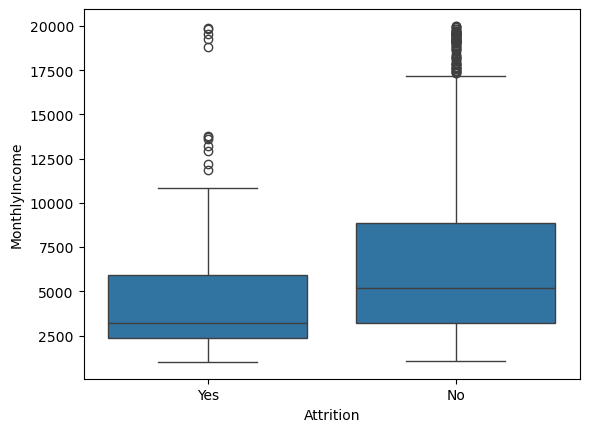

In [49]:
# Attrition x MontlyIncome
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)

In [50]:
df['JobRole'].describe()

count                1470
unique                  9
top       Sales Executive
freq                  326
Name: JobRole, dtype: object

<Axes: xlabel='JobRole'>

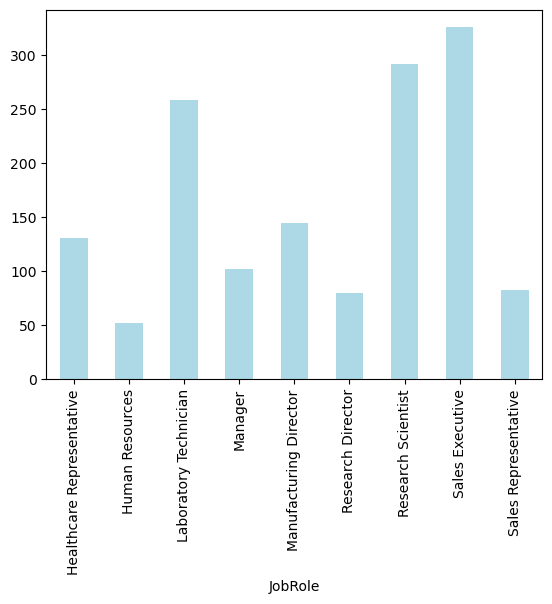

In [51]:
job_role = df.groupby(['JobRole']).size()
job_role.plot.bar(color = 'lightblue')

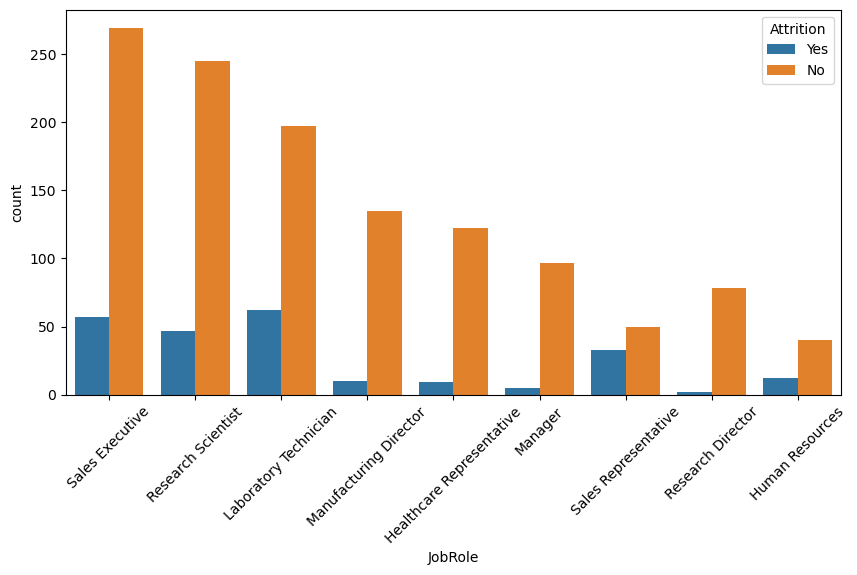

In [52]:
# Attrition x JobRole
plt.figure(figsize=(10,5))
sns.countplot(x='JobRole', hue='Attrition', data=df)
plt.xticks(rotation=45)
plt.show()

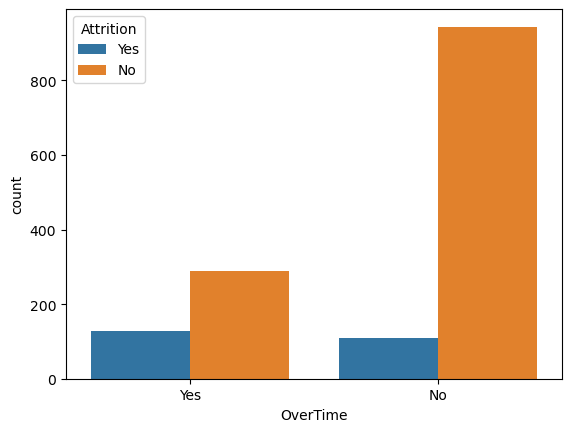

In [53]:
# OverTime x Attrition
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.show()

In [54]:
df['YearsAtCompany'].describe()

count    1470.000000
mean        7.008163
std         6.126525
min         0.000000
25%         3.000000
50%         5.000000
75%         9.000000
max        40.000000
Name: YearsAtCompany, dtype: float64

In [55]:
df['OverTime'].value_counts()

No     1054
Yes     416
Name: OverTime, dtype: int64

In [56]:
df['WorkLifeBalance'].value_counts()

3    893
2    344
4    153
1     80
Name: WorkLifeBalance, dtype: int64

In [57]:
df['JobSatisfaction'].value_counts()

4    459
3    442
1    289
2    280
Name: JobSatisfaction, dtype: int64

In [58]:
df['EnvironmentSatisfaction'].value_counts()

3    453
4    446
2    287
1    284
Name: EnvironmentSatisfaction, dtype: int64

In [59]:
# Nova coluna: Funcionário novo
df['IsJunior'] = (df['YearsAtCompany'] < 2).astype(int)

In [60]:
df['IsJunior'].value_counts()

0    1255
1     215
Name: IsJunior, dtype: int64

In [61]:
df['OverTime'] = df['OverTime'].map({'No': 0, 'Yes': 1})

In [62]:
# Nova coluna: Risco de Burnout
df['BurnoutRisk'] = ((df['OverTime'] == 1) & (df['WorkLifeBalance'] <= 2)).astype(int)

In [63]:
df['BurnoutRisk'].value_counts()

0    1344
1     126
Name: BurnoutRisk, dtype: int64

In [64]:
# Nova coluna: Baixa satisfação geral
df['LowSatisfaction'] = (
    (df['JobSatisfaction'] <= 2) &
    (df['EnvironmentSatisfaction'] <= 2)
).astype(int)

In [65]:
df['LowSatisfaction'].value_counts()

0    1256
1     214
Name: LowSatisfaction, dtype: int64